<a href="https://colab.research.google.com/github/ian-menachery/ECON3916-Statistical-Machine-Learning/blob/main/%5BClass_3_%7C_Lab%5D_Visualizing_Development_with_WBGAPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import wbgapi as wb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define Economies: GTM (Guatemala), UMC (Upper Middle Income), WLD (World)
country_codes = ['GTM', 'UMC', 'WLD']

indicators = {
    'NY.GDP.PCAP.KD': 'GDP_Per_Capita_Const',     # Standard of Living
    'SL.TLF.CACT.ZS': 'Labor_Part_Rate',          # Labor Supply
    'SL.UEM.TOTL.ZS': 'Unemployment_Rate',        # Labor Friction
    'SL.TLF.TOTL.IN': 'Labor_Force_Total',        # Total Workers
    'NY.GDP.MKTP.KD': 'GDP_Const',                # Economic Size
    'FP.CPI.TOTL.ZG': 'Inflation_CPI',            # Stability
    'NY.GDS.TOTL.ZS': 'Gross_Dom_Savings',        # Savings
    'NE.GDI.TOTL.ZS': 'Gross_Cap_Formation',      # Investment
    'NE.EXP.GNFS.ZS': 'Exports_GDP',              # Exports
    'NE.IMP.GNFS.ZS': 'Imports_GDP',              # Imports
    'GC.TAX.TOTL.GD.ZS': 'Tax_Rev_GDP',           # Gov Revenue
    'NE.CON.GOVT.ZS': 'Gov_Exp_GDP'               # Gov Spending
}

In [3]:
# 1. Fetch Data
print("Fetching data...")
df_raw = wb.data.DataFrame(indicators, economy=country_codes, time=range(2000, 2025))

# 2. Transpose (Flip Rows/Cols)
df = df_raw.T

# 3. Clean Index
df.index = df.index.str.replace('YR', '').astype(int)
df.index.name = 'Year'
df = df.sort_index()

# 4. Rename Columns
df.rename(columns=indicators, level=1, inplace=True)

# 5. Extract Guatemala for specific calculations
df_gtm = df.xs('GTM', axis=1, level=0).copy()

Fetching data...


In [4]:
# 1. Natural Rate of Unemployment (5-Year MA)
df_gtm['Natural_Rate_Unemp'] = df_gtm['Unemployment_Rate'].rolling(window=5).mean()

# 2. Productivity (Output per Worker)
df_gtm['Productivity'] = df_gtm['GDP_Const'] / df_gtm['Labor_Force_Total']

# 3. Net Capital Outflow (Exports - Imports)
df_gtm['NCO'] = df_gtm['Exports_GDP'] - df_gtm['Imports_GDP']

# 4. Budget Balance (Tax - Spending)
df_gtm['Budget_Balance'] = df_gtm['Tax_Rev_GDP'] - df_gtm['Gov_Exp_GDP']

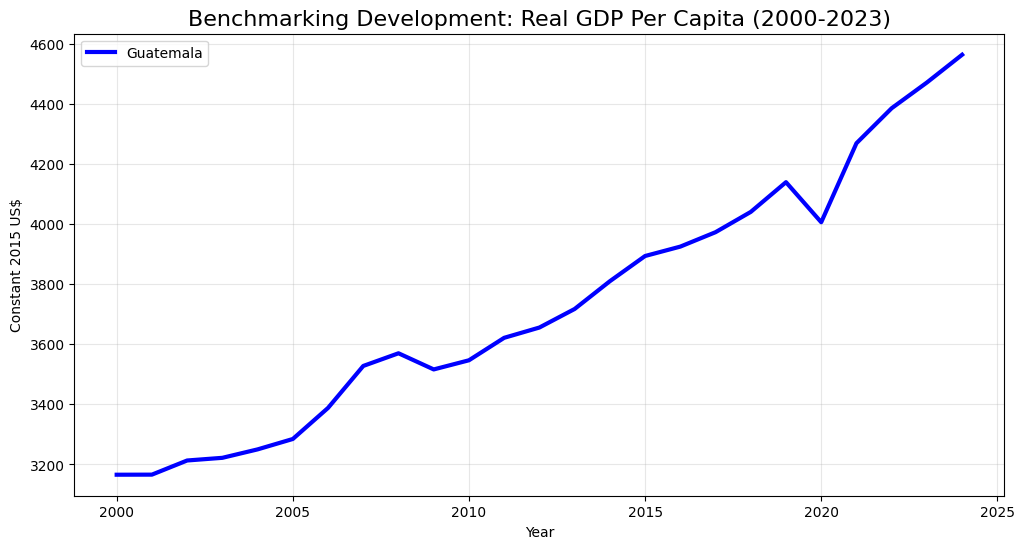

In [5]:
plt.figure(figsize=(12, 6))
# Plot ONLY Guatemala
plt.plot(df.index, df[('GTM', 'GDP_Per_Capita_Const')], label='Guatemala', color='blue', linewidth=3)
plt.title('Benchmarking Development: Real GDP Per Capita (2000-2023)', fontsize=16)
plt.ylabel('Constant 2015 US$')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

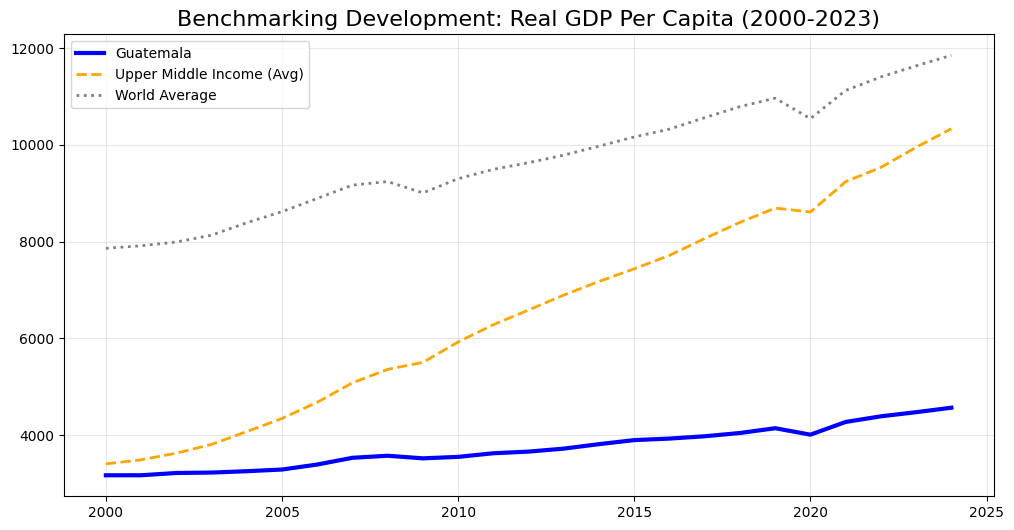

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df[('GTM', 'GDP_Per_Capita_Const')], label='Guatemala', color='blue', linewidth=3)
# ADD THESE LINES
plt.plot(df.index, df[('UMC', 'GDP_Per_Capita_Const')], label='Upper Middle Income (Avg)', color='orange', linestyle='--', linewidth=2)
plt.plot(df.index, df[('WLD', 'GDP_Per_Capita_Const')], label='World Average', color='grey', linestyle=':', linewidth=2)

plt.title('Benchmarking Development: Real GDP Per Capita (2000-2023)', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

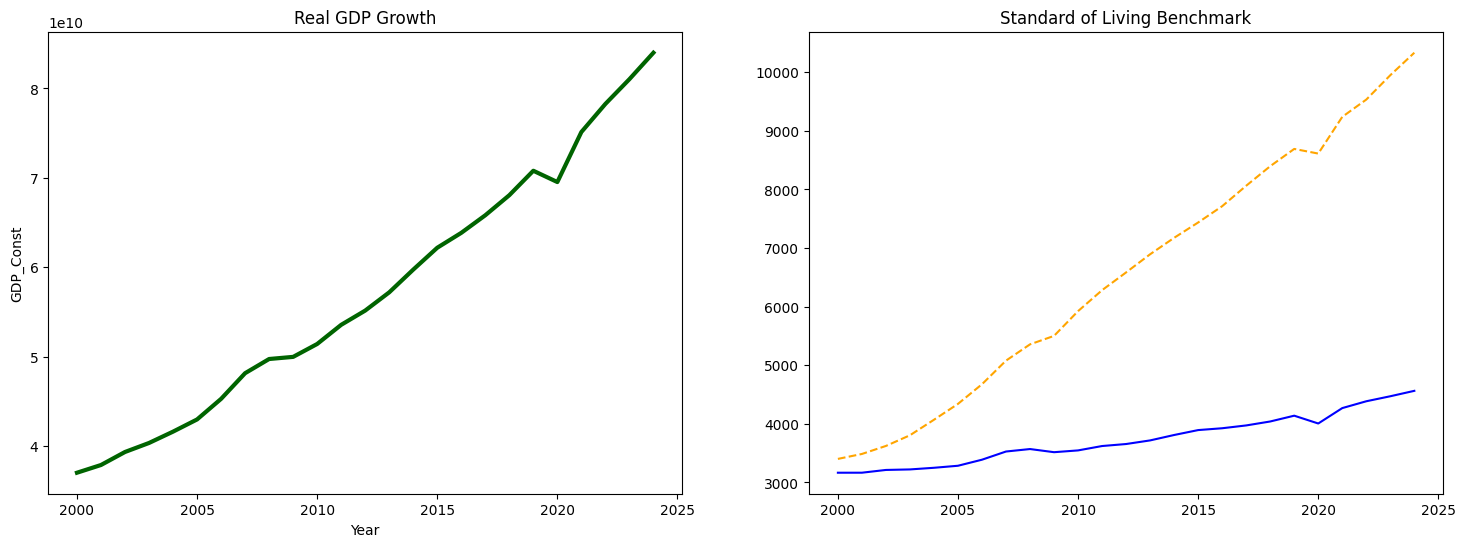

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Chart A: Total GDP
sns.lineplot(data=df_gtm, x=df_gtm.index, y='GDP_Const', color='darkgreen', linewidth=3, ax=ax1)
ax1.set_title('Real GDP Growth')

# Chart B: GDP Per Capita Benchmark
ax2.plot(df.index, df[('GTM', 'GDP_Per_Capita_Const')], color='blue')
ax2.plot(df.index, df[('UMC', 'GDP_Per_Capita_Const')], color='orange', linestyle='--')
ax2.set_title('Standard of Living Benchmark')
plt.show()

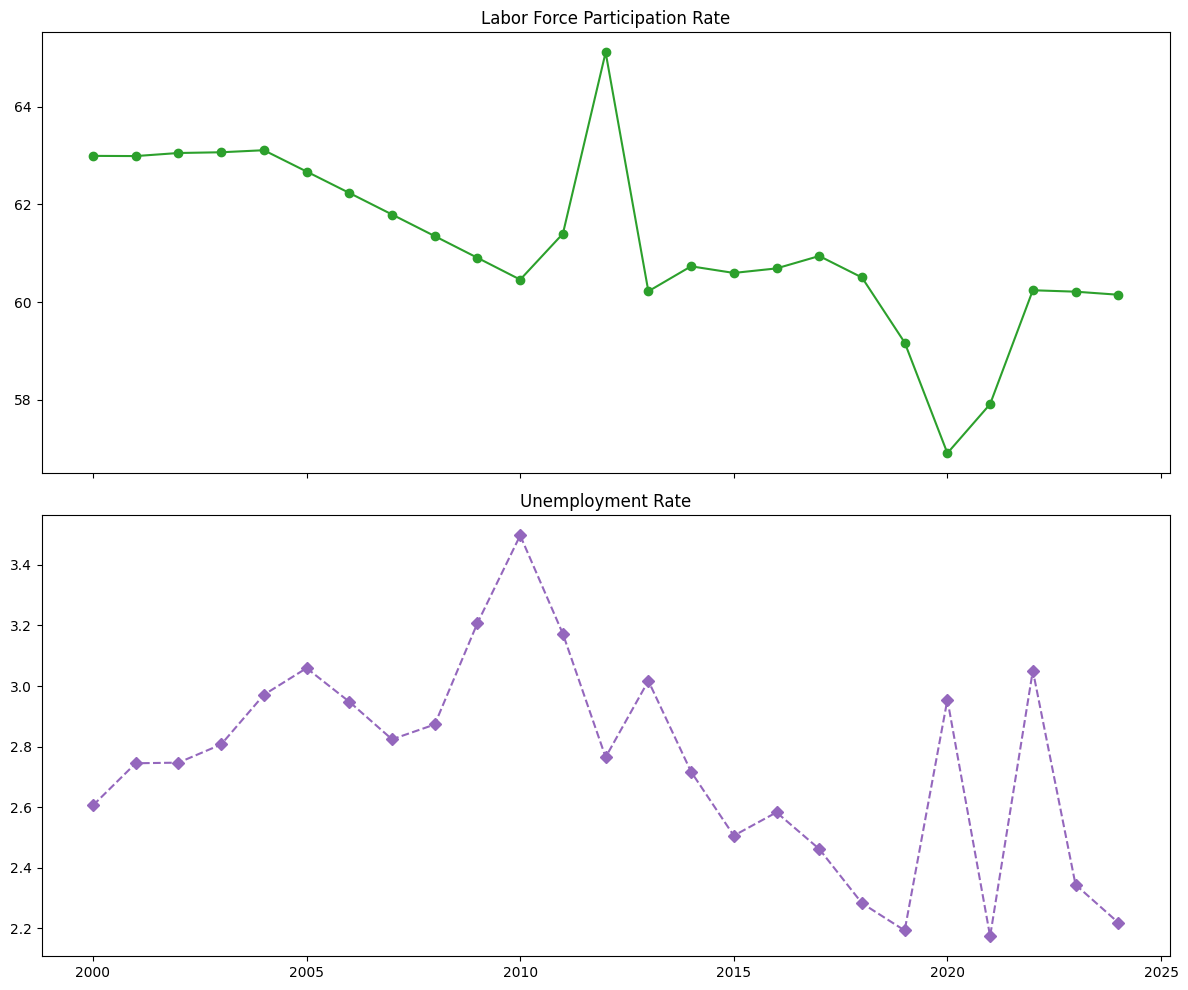

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top: Participation
ax1.plot(df_gtm.index, df_gtm['Labor_Part_Rate'], color='tab:green', marker='o')
ax1.set_title('Labor Force Participation Rate')

# Bottom: Unemployment
ax2.plot(df_gtm.index, df_gtm['Unemployment_Rate'], color='tab:purple', marker='D', linestyle='--')
ax2.set_title('Unemployment Rate')
plt.tight_layout()
plt.show()

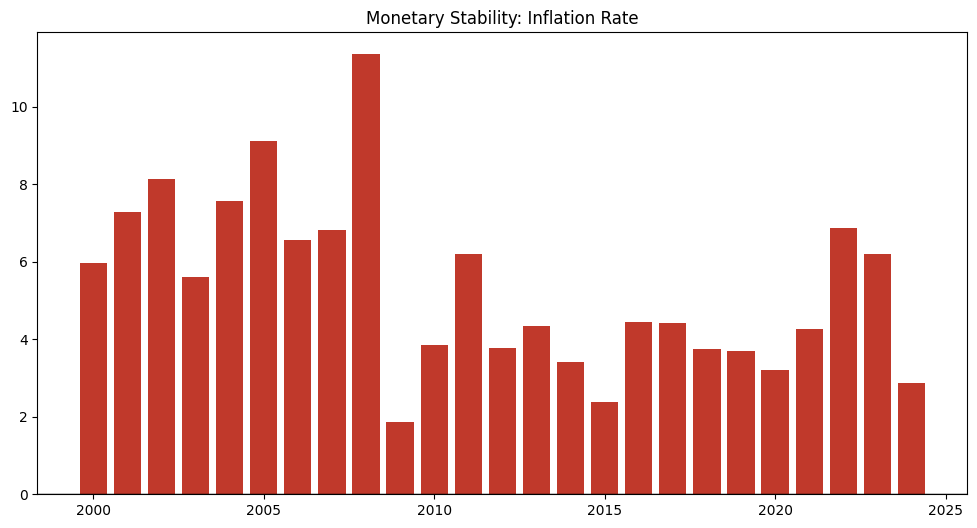

In [9]:
plt.figure(figsize=(12, 6))

plt.bar(df_gtm.index, df_gtm['Inflation_CPI'], color='#c0392b')

plt.axhline(0, color='black', linewidth=1)
plt.title('Monetary Stability: Inflation Rate')
plt.show()

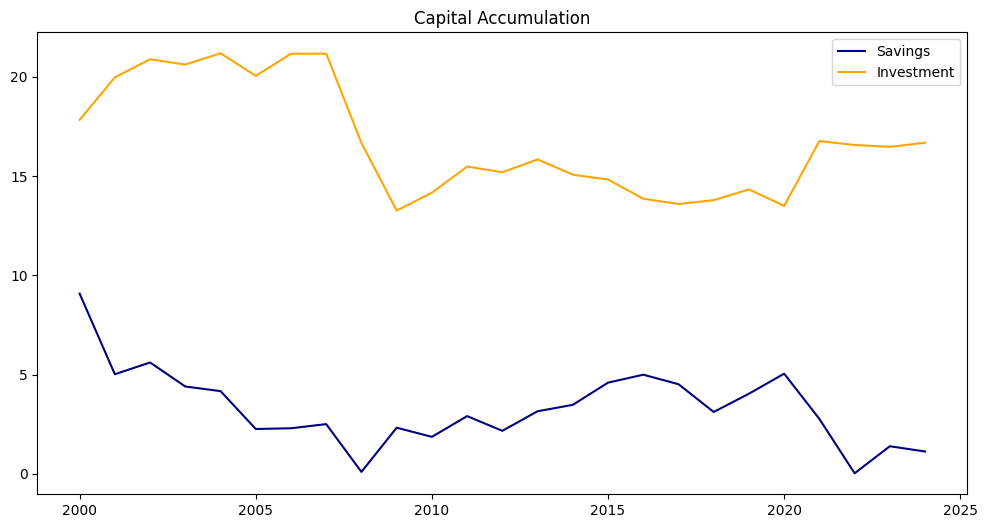

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df_gtm.index, df_gtm['Gross_Dom_Savings'], label='Savings', color='navy')
plt.plot(df_gtm.index, df_gtm['Gross_Cap_Formation'], label='Investment', color='orange')
plt.title('Capital Accumulation')
plt.legend()
plt.show()

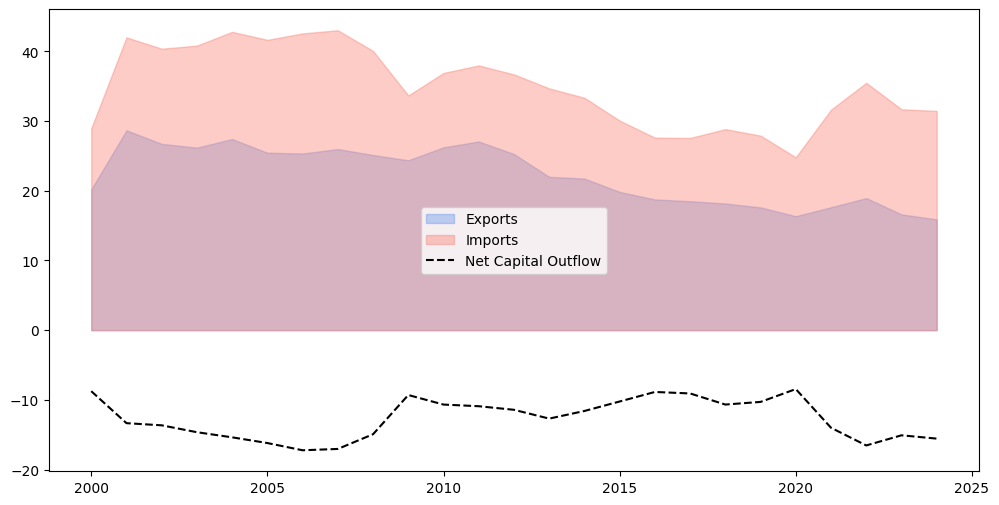

In [11]:
plt.figure(figsize=(12, 6))
plt.fill_between(df_gtm.index, df_gtm['Exports_GDP'], color='cornflowerblue', alpha=0.4, label='Exports')
plt.fill_between(df_gtm.index, df_gtm['Imports_GDP'], color='salmon', alpha=0.4, label='Imports')
plt.plot(df_gtm.index, df_gtm['NCO'], color='black', linestyle='--', label='Net Capital Outflow')
plt.legend()
plt.show()

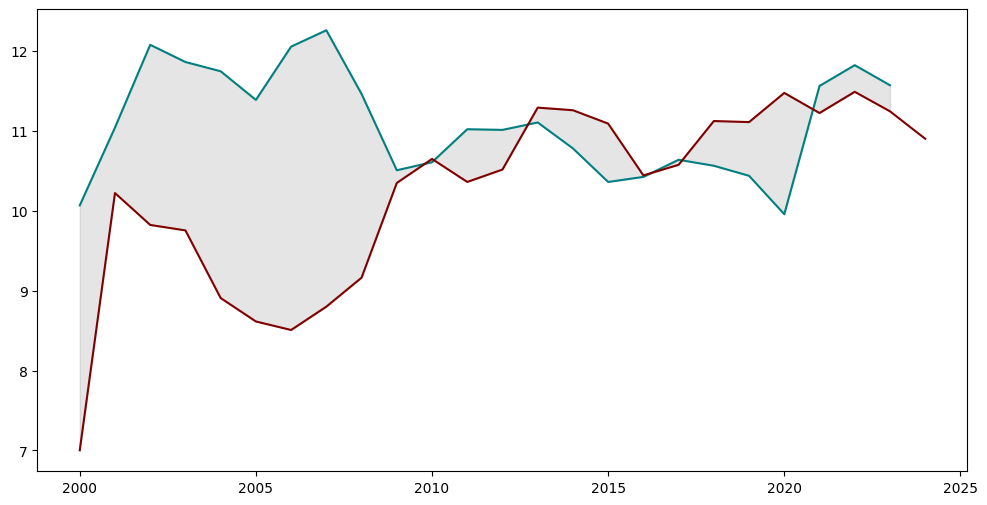

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df_gtm.index, df_gtm['Tax_Rev_GDP'], label='Revenue', color='teal')
plt.plot(df_gtm.index, df_gtm['Gov_Exp_GDP'], label='Expenditure', color='maroon')
plt.fill_between(df_gtm.index, df_gtm['Tax_Rev_GDP'], df_gtm['Gov_Exp_GDP'], color='gray', alpha=0.2)
plt.show()

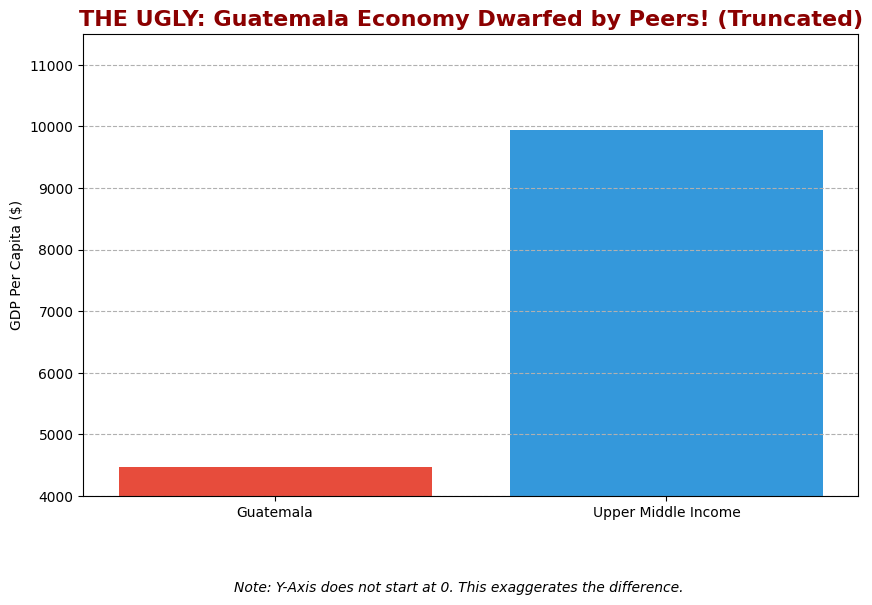

In [13]:
# THE UGLY CHART
# Setup snapshot data for the latest available year
snapshot_year = 2023
gtm_val = df.loc[snapshot_year, ('GTM', 'GDP_Per_Capita_Const')]
umc_val = df.loc[snapshot_year, ('UMC', 'GDP_Per_Capita_Const')]

values = [gtm_val, umc_val]
labels = ['Guatemala', 'Upper Middle Income']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#e74c3c', '#3498db'])

# THE VIOLATION: Truncating the axis
# Guatemala is approx 4600. UMC is approx 11000.
# Starting axis at 4000 makes GTM look tiny.
plt.ylim(4000, 11500)

plt.title('THE UGLY: Guatemala Economy Dwarfed by Peers! (Truncated)', fontsize=16, fontweight='bold', color='darkred')
plt.ylabel('GDP Per Capita ($)')
plt.grid(axis='y', linestyle='--')
plt.figtext(0.5, -0.05, "Note: Y-Axis does not start at 0. This exaggerates the difference.", ha="center", style='italic')

plt.show()

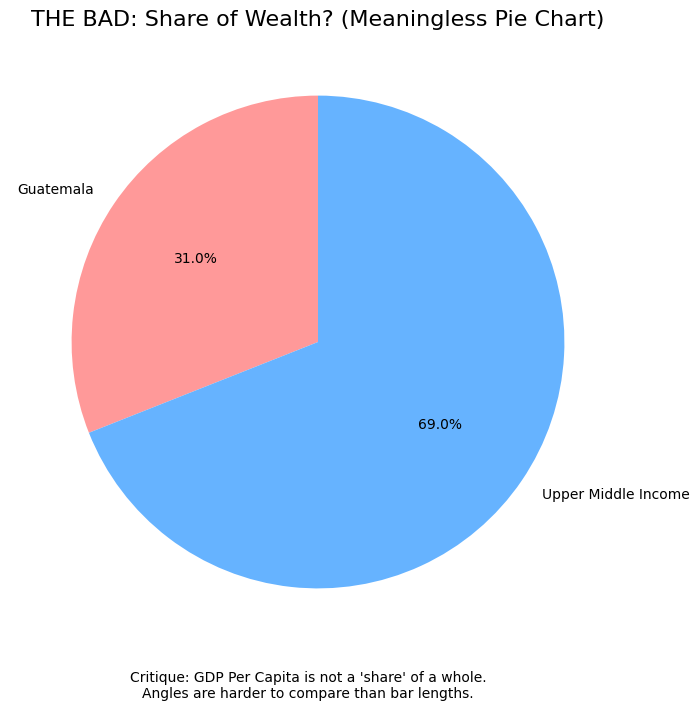

In [14]:
# CELL 9: THE BAD CHART
plt.figure(figsize=(8, 8))

# THE VIOLATION: Using a Pie Chart for non-summable data (GDP Per Capita)
# Comparison of magnitudes should be a Bar Chart, not angles.
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)

plt.title('THE BAD: Share of Wealth? (Meaningless Pie Chart)', fontsize=16)
plt.figtext(0.5, 0.05, "Critique: GDP Per Capita is not a 'share' of a whole.\nAngles are harder to compare than bar lengths.", ha="center")

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/guatemala_dashboard.png'

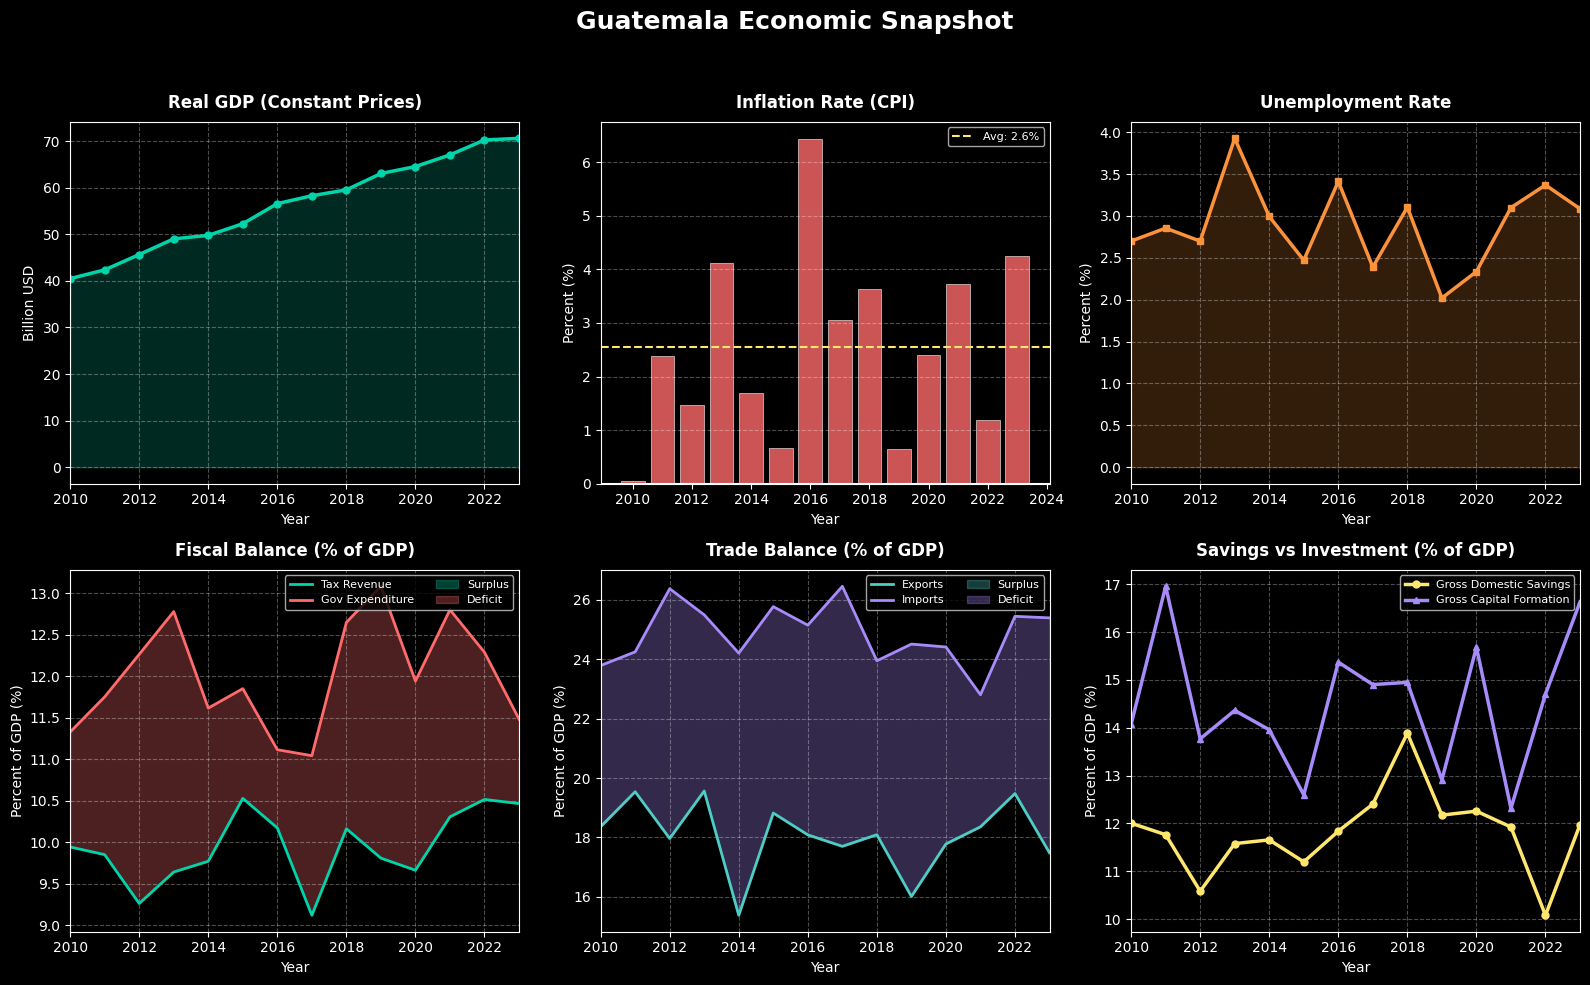

In [15]:
"""
Guatemala Economic Dashboard - 2x3 Executive Summary
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Sample data for Guatemala (replace with your actual df_gtm)
np.random.seed(42)
years = list(range(2010, 2024))

df_gtm = pd.DataFrame({
    'Year': years,
    'GDP_Const': [40 + i * 2.5 + np.random.normal(0, 1) for i in range(len(years))],  # Billions USD
    'Inflation_CPI': [3.5 + np.random.normal(0, 2) for _ in years],  # Percentage
    'Unemployment_Rate': [3.0 + np.random.normal(0, 0.5) for _ in years],  # Percentage
    'Tax_Rev_GDP': [10 + np.random.normal(0, 0.5) for _ in years],  # % of GDP
    'Gov_Exp_GDP': [12 + np.random.normal(0, 0.8) for _ in years],  # % of GDP
    'Exports_GDP': [18 + np.random.normal(0, 1) for _ in years],  # % of GDP
    'Imports_GDP': [25 + np.random.normal(0, 1.5) for _ in years],  # % of GDP
    'Gross_Dom_Savings': [12 + np.random.normal(0, 1) for _ in years],  # % of GDP
    'Gross_Cap_Formation': [14 + np.random.normal(0, 1.2) for _ in years],  # % of GDP
})

# Apply dark background style
plt.style.use('dark_background')

# Create the 2x3 figure
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Color palette
colors = {
    'primary': '#00D4AA',
    'secondary': '#FF6B6B',
    'accent': '#4ECDC4',
    'highlight': '#FFE66D',
    'purple': '#A78BFA',
    'orange': '#FB923C'
}

# ============================================================
# TOP LEFT: Real GDP (Line Chart)
# ============================================================
ax1 = axes[0, 0]
ax1.plot(df_gtm['Year'], df_gtm['GDP_Const'],
         color=colors['primary'], linewidth=2.5, marker='o', markersize=5)
ax1.fill_between(df_gtm['Year'], df_gtm['GDP_Const'], alpha=0.2, color=colors['primary'])
ax1.set_title('Real GDP (Constant Prices)', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('Billion USD', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(df_gtm['Year'].min(), df_gtm['Year'].max())

# ============================================================
# TOP MIDDLE: Inflation Rate (Bar Chart with 0 line)
# ============================================================
ax2 = axes[0, 1]
bar_colors = [colors['secondary'] if x > 0 else colors['accent'] for x in df_gtm['Inflation_CPI']]
ax2.bar(df_gtm['Year'], df_gtm['Inflation_CPI'], color=bar_colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax2.axhline(y=0, color='white', linestyle='-', linewidth=1.5)
ax2.axhline(y=df_gtm['Inflation_CPI'].mean(), color=colors['highlight'], linestyle='--',
            linewidth=1.5, label=f"Avg: {df_gtm['Inflation_CPI'].mean():.1f}%")
ax2.set_title('Inflation Rate (CPI)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('Percent (%)', fontsize=10)
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')

# ============================================================
# TOP RIGHT: Unemployment Rate (Line Chart)
# ============================================================
ax3 = axes[0, 2]
ax3.plot(df_gtm['Year'], df_gtm['Unemployment_Rate'],
         color=colors['orange'], linewidth=2.5, marker='s', markersize=5)
ax3.fill_between(df_gtm['Year'], df_gtm['Unemployment_Rate'], alpha=0.2, color=colors['orange'])
ax3.set_title('Unemployment Rate', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('Year', fontsize=10)
ax3.set_ylabel('Percent (%)', fontsize=10)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xlim(df_gtm['Year'].min(), df_gtm['Year'].max())

# ============================================================
# BOTTOM LEFT: Fiscal Balance (Area between Tax Rev & Gov Exp)
# ============================================================
ax4 = axes[1, 0]
ax4.plot(df_gtm['Year'], df_gtm['Tax_Rev_GDP'],
         color=colors['primary'], linewidth=2, label='Tax Revenue')
ax4.plot(df_gtm['Year'], df_gtm['Gov_Exp_GDP'],
         color=colors['secondary'], linewidth=2, label='Gov Expenditure')
ax4.fill_between(df_gtm['Year'], df_gtm['Tax_Rev_GDP'], df_gtm['Gov_Exp_GDP'],
                 where=(df_gtm['Tax_Rev_GDP'] >= df_gtm['Gov_Exp_GDP']),
                 color=colors['primary'], alpha=0.3, interpolate=True, label='Surplus')
ax4.fill_between(df_gtm['Year'], df_gtm['Tax_Rev_GDP'], df_gtm['Gov_Exp_GDP'],
                 where=(df_gtm['Tax_Rev_GDP'] < df_gtm['Gov_Exp_GDP']),
                 color=colors['secondary'], alpha=0.3, interpolate=True, label='Deficit')
ax4.set_title('Fiscal Balance (% of GDP)', fontsize=12, fontweight='bold', pad=10)
ax4.set_xlabel('Year', fontsize=10)
ax4.set_ylabel('Percent of GDP (%)', fontsize=10)
ax4.legend(loc='upper right', fontsize=8, ncol=2)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xlim(df_gtm['Year'].min(), df_gtm['Year'].max())

# ============================================================
# BOTTOM MIDDLE: Trade Balance (Area between Exports & Imports)
# ============================================================
ax5 = axes[1, 1]
ax5.plot(df_gtm['Year'], df_gtm['Exports_GDP'],
         color=colors['accent'], linewidth=2, label='Exports')
ax5.plot(df_gtm['Year'], df_gtm['Imports_GDP'],
         color=colors['purple'], linewidth=2, label='Imports')
ax5.fill_between(df_gtm['Year'], df_gtm['Exports_GDP'], df_gtm['Imports_GDP'],
                 where=(df_gtm['Exports_GDP'] >= df_gtm['Imports_GDP']),
                 color=colors['accent'], alpha=0.3, interpolate=True, label='Surplus')
ax5.fill_between(df_gtm['Year'], df_gtm['Exports_GDP'], df_gtm['Imports_GDP'],
                 where=(df_gtm['Exports_GDP'] < df_gtm['Imports_GDP']),
                 color=colors['purple'], alpha=0.3, interpolate=True, label='Deficit')
ax5.set_title('Trade Balance (% of GDP)', fontsize=12, fontweight='bold', pad=10)
ax5.set_xlabel('Year', fontsize=10)
ax5.set_ylabel('Percent of GDP (%)', fontsize=10)
ax5.legend(loc='upper right', fontsize=8, ncol=2)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_xlim(df_gtm['Year'].min(), df_gtm['Year'].max())

# ============================================================
# BOTTOM RIGHT: Savings vs Investment (Dual Lines)
# ============================================================
ax6 = axes[1, 2]
ax6.plot(df_gtm['Year'], df_gtm['Gross_Dom_Savings'],
         color=colors['highlight'], linewidth=2.5, marker='o', markersize=5, label='Gross Domestic Savings')
ax6.plot(df_gtm['Year'], df_gtm['Gross_Cap_Formation'],
         color=colors['purple'], linewidth=2.5, marker='^', markersize=5, label='Gross Capital Formation')
ax6.set_title('Savings vs Investment (% of GDP)', fontsize=12, fontweight='bold', pad=10)
ax6.set_xlabel('Year', fontsize=10)
ax6.set_ylabel('Percent of GDP (%)', fontsize=10)
ax6.legend(loc='upper right', fontsize=8)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_xlim(df_gtm['Year'].min(), df_gtm['Year'].max())

# ============================================================
# Main Title and Layout
# ============================================================
fig.suptitle('Guatemala Economic Snapshot', fontsize=18, fontweight='bold', y=0.98, color='white')

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save the figure
plt.savefig('/home/claude/guatemala_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e', edgecolor='none')

print("Dashboard saved successfully!")
plt.show()